# Paper Plots/Animations

Plots for the upcoming paper; most of which are found in other notebooks in this repository, but just putting them all here to have a record.

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from pathlib import Path
import os
import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import pandas as pd
from matplotlib.cm import prism
from matplotlib.cm import Set3
import numpy as np
from scipy import stats

curwd = os.getcwd()
os.chdir(str(Path(os.getcwd()).parents[0]) + '/scripts/')
import utils
from utils import display_catalog
os.chdir(str(Path(os.getcwd())) + '/clustering/')
import st_dbscan as st
os.chdir(curwd)
home_dir = Path(curwd).parents[0]


## Main Paper

### Tracker

#### Algorithm Details

Showing how stage 1 of the two-stage clustering works.

In [2]:
catalogs = utils.load_catalogs(years=[1980])

In [3]:
subcatalog = catalogs.isel(time=slice(120, 140))

# hyperparameters  
synoptic_scale = 10**3
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian

eps_space = synoptic_scale/(2*km_per_radian) # converted to radians for Haversine metric
eps_space_1 = eps_space
eps_space_2 = eps_space
eps_time = 18/24
minpts_1 = 5
minpts_2 = 5
n_rep_pts = 10

# instantiating the clustering object
cluster_obj = st.ST_DBSCAN(eps_space_1, eps_space_2, eps_time, minpts_1, minpts_2, n_rep_pts)
# doing the spatiotemporal clustering
df = cluster_obj.fit(subcatalog)

Beginning spatial clustering step.


100%|██████████| 20/20 [00:03<00:00,  5.53it/s]
/global/u1/j/jbbutler/extreme_antarctic_ARs/scripts/clustering/st_dbscan.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.


In [4]:
time = df.iloc[9].time

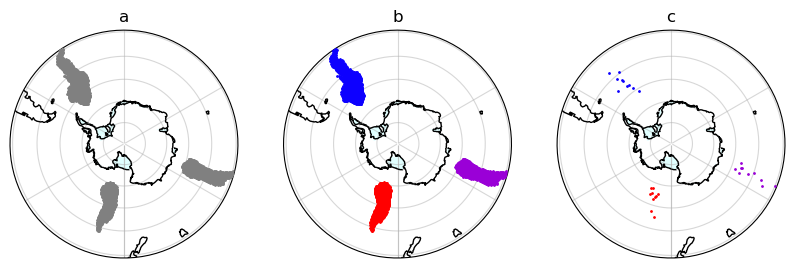

In [5]:
# instantiate the animation
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))

unique_clusters = df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism(j/12) for j in range(len(unique_clusters)) }

if (time == df.time).any():
    dat = df[df['time'] == time]
    n_clusts = dat.shape[0]

    for i in range(n_clusts):
        cluster = dat['cluster'].iloc[i]
        ax[0].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color='gray', zorder=30)
        ax[1].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
        ax[2].scatter(dat['rep_lons'].iloc[i], dat['rep_lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)

for i in range(len(ax)):

    ax[i].set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax[i].coastlines(resolution='110m',linewidth=1,zorder=32)

    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax[i].set_boundary(circle, transform=ax[i].transAxes)
    ax[i].gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time)
    
ax[0].set_title('a')
ax[1].set_title('b')
ax[2].set_title('c')

plt.savefig('../plots/paper_plots/spatial_clustering.png', bbox_inches='tight')

Showing how stage 2 of the clustering algorithm works.

In [6]:
unpacked_df = cluster_obj.unpack_df(df, 'cluster')

In [7]:
unpacked_df = unpacked_df[unpacked_df.time.dt.day == 8]

In [8]:
unpacked_df = unpacked_df[unpacked_df.time.dt.hour % 6 == 0]

In [9]:
ais_mask = np.radians(np.array(list(utils.load_ais())))

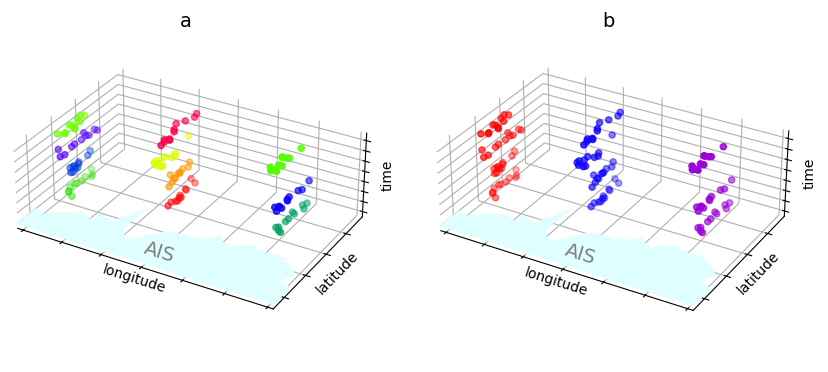

In [10]:
fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,2,2, projection='3d')
ax.scatter(unpacked_df.lon, unpacked_df.lat, unpacked_df.time.dt.hour, c=prism((unpacked_df.cluster-1)/12))
ax.scatter(ais_mask[:,1], ais_mask[:,0], 0, c='lightcyan', s=0.5, zorder=30)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('longitude', labelpad=-12)
ax.set_ylabel('latitude', labelpad=-12)
ax.set_zlabel('time', rotation=90, labelpad=-12)
ax.axes.set_ylim3d(bottom=min(ais_mask[:,0]))
ax.axes.set_xlim3d(left=min(ais_mask[:,1]))
ax.axes.set_xlim3d(right=max(ais_mask[:,1]))
ax.view_init(azim=-60, elev=30)
ax.set_box_aspect((1.45, 1, 0.5))
ax.text(x=0, y=-1.5, z=0, s='AIS', zorder=31, c='gray', zdir='x', fontsize=14)
ax.set_title('b', fontsize=14, y=1.01)

ax = fig.add_subplot(1,2,1, projection='3d')
ax.scatter(unpacked_df.lon, unpacked_df.lat, unpacked_df.time.dt.hour, c=prism((unpacked_df.space_cluster-1)/20))
ax.scatter(ais_mask[:,1], ais_mask[:,0], 0, c='lightcyan', s=0.5)
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])
ax.set_xlabel('longitude', labelpad=-12)
ax.set_ylabel('latitude', labelpad=-12)
ax.set_zlabel('time', rotation=90, labelpad=-12)
ax.axes.set_ylim3d(bottom=min(ais_mask[:,0]))
ax.axes.set_xlim3d(left=min(ais_mask[:,1]))
ax.axes.set_xlim3d(right=max(ais_mask[:,1]))
ax.view_init(azim=-60, elev=30)
ax.set_title('a', fontsize=14, y=1.01)
ax.set_box_aspect((1.5, 1, 0.5))
ax.text(x=0, y=-1.5, z=0, s='AIS', zorder=31, c='gray', zdir='x', fontsize=14);

plt.savefig('../plots/paper_plots/spatiotemporal_stitching.png', bbox_inches='tight')

#### Catalog Summaries

In [12]:
catalog_path = '/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/landfalling_storm_quantities_df.h5'
landfalling_catalog = pd.read_hdf(catalog_path)

In [144]:
full_path = '/global/homes/j/jbbutler/extreme_antarctic_ARs/data/ar_database/dataframe_eps12_eps500_minpts5_reppts10/storm_df.h5'
full_catalog = pd.read_hdf(full_path)

In [145]:
def coarsen_regions(region):
    if region in ['MBL', 'ELS', 'AP', 'FRIS']:
        return 'West'
    elif region in ['QML', 'END']:
        return 'East 1'
    else:
        return 'East 2'

landfalling_catalog['coarser_region'] = landfalling_catalog.region.apply(coarsen_regions)

In [146]:
# getting areas of each region, in km2
def find_region_masks(region_defs, ais_da):
    '''
    Helper function for the above find_landfalling_region function. Given longitude bounds for each region,
    find binary masks for each of these from the AIS mask
    
    Inputs:
        region_defs (dictionary): dictionary whose keys are strings indicating names of regions and
            values are lists with lower and upper longitude bounds for the regions
        ais_da (xarray.DataArray): the binary mask for the AIS
    Output:
        region_masks (dictionary): keys are names of regions (strings), and values are DataArray masks for
            just that region
    '''

    region_masks = {}

    for label, bound in region_defs.items():
        if bound[0] > bound[1]: # if we're crossing the dateline
            region_masks[label] = ais_da.where(((ais_da.lon > bound[0]) & (ais_da.lon <= 180)) | ((ais_da.lon >= -180) & (ais_da.lon < bound[1])), False)
        else: # normal case
            region_masks[label] = ais_da.where((ais_da.lon > bound[0]) & (ais_da.lon < bound[1]), False)

    return region_masks

region_defs = {'MBL': [-150, -120], 
               'ELS': [-120, -75],
               'AP': [-75, -50],
               'FRIS': [-50, -30],
               'QML': [-30, 30],
               'END': [30, 75],
               'QMC': [75, 120],
               'WLK': [120, 150],
               'VICT': [150, 180],
               'RIS': [-180, -150]}

region_defs_coarser = {'West': [-150, -30], 
               'East 1': [-30, 75],
               'East 2': [75, -150]}

ais_mask = xr.open_dataset('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/antarctic_masks/AIS_Full_basins_Zwally_MERRA2grid_new.nc')
ais_mask = ais_mask.Zwallybasins > 0
region_masks = find_region_masks(region_defs, ais_mask)
region_masks_coarser = find_region_masks(region_defs_coarser, ais_mask)

In [147]:
cell_areas = xr.open_dataset('/global/homes/j/jbbutler/extreme_antarctic_ARs/data/area/MERRA2_gridarea.nc')
cell_areas = cell_areas.cell_area
region_areas = {}

for region, mask in region_masks_coarser.items():
    region_areas[region] = mask.dot(cell_areas).values/(10**6)

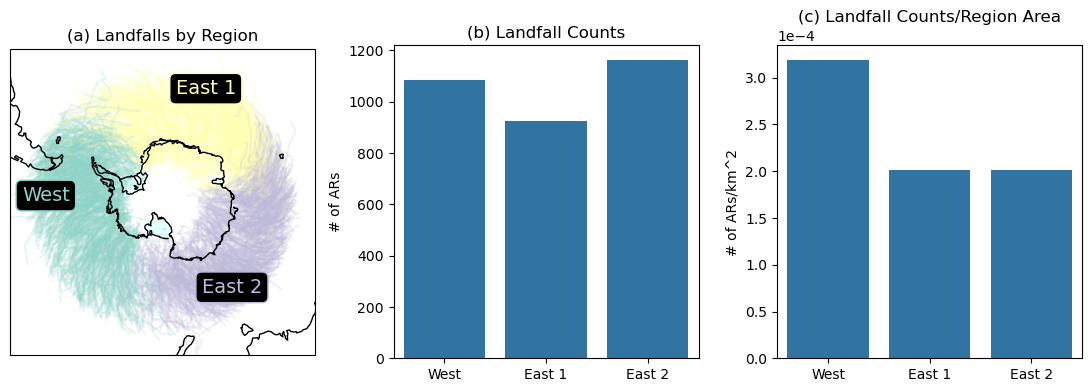

In [148]:
fig = plt.figure(figsize=(11,4))
ax1 = plt.subplot(131, projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.))

for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory
    ax1.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color=color_mapping_coarser[row.coarser_region], alpha=0.2)

for label in region_defs_coarser.keys():
    if label == 'East 2':
        ax1.text((region_defs_coarser[label][0] + region_defs_coarser[label][1])/2 + 180, -53, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping_coarser[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping_coarser[label], zorder=40)
    else:
        ax1.text((region_defs_coarser[label][0] + region_defs_coarser[label][1])/2, -53, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping_coarser[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping_coarser[label], zorder=40)



ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax1.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax1.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax1.coastlines(resolution='110m',linewidth=1,zorder=32)
ax1.set_extent([-180,180,-90,-42], ccrs.PlateCarree())
ax1.set_title('(a) Landfalls by Region')
ax1.grid(True, linestyle='--', color='gray', alpha=0.5)

    
# Map extent 
#ax.gridlines(alpha=0.5, zorder=33)
#fig.savefig(str(home_dir) + '/plots/paper_plots/regional_trajectory_map.png', dpi=100)
ax2 = plt.subplot(132)
sns.countplot(landfalling_catalog, x='coarser_region', ax=ax2, order=['West', 'East 1', 'East 2'])
ax2.set_title('(b) Landfall Counts')
ax2.set_ylabel('# of ARs')
ax2.set_xlabel('')

ax3 = plt.subplot(133)
region_df = landfalling_catalog.groupby('coarser_region').size()
region_df = pd.concat([region_df.rename('count'), pd.Series(region_areas).rename('area')], axis=1, names=['coarser_region', 'area'])
region_df['storms_per_area'] = region_df['count']/region_df['area']
sns.barplot(data=region_df, x=region_df.index, y='storms_per_area', ax=ax3, order=['West', 'East 1', 'East 2'])
ax3.set_title('(c) Landfall Counts/Region Area')
ax3.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
ax3.set_ylabel('# of ARs/km^2')
ax3.set_xlabel('')

fig.tight_layout(pad=1)
fig.savefig(str(home_dir) + '/plots/paper_plots/regional_counts.png', dpi=100)

In [149]:
years = landfalling_catalog.start_date.dt.year
landfalling_catalog['landfalling_year'] = years
year_df = landfalling_catalog.groupby('landfalling_year', as_index=False).size()

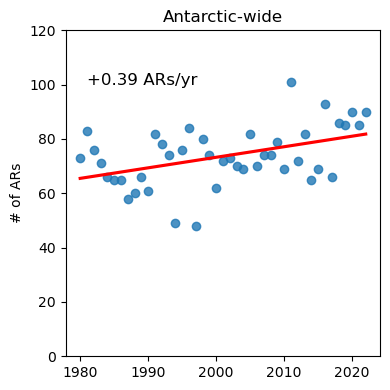

In [150]:
year_df = landfalling_catalog.groupby('landfalling_year', as_index=False).size()

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(4,4))
coord = 0

cur_ax =axs

sns.regplot(data=year_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
ar_rate = round(stats.linregress(year_df.landfalling_year, year_df['size'])[0], 2)
text = f'+{ar_rate} ARs/yr'
cur_ax.set_title('Antarctic-wide')
cur_ax.set_ylim([0, 120])
cur_ax.text(1981, 100, s=text, fontsize=12)
cur_ax.set_xlabel('')
cur_ax.set_ylabel('# of ARs')

fig.tight_layout()
fig.savefig(str(home_dir) + '/plots/paper_plots/antarctic_count_trend.png', dpi=100)

In [151]:
year_df['size'].describe()

count     43.000000
mean      73.651163
std       10.984586
min       48.000000
25%       66.000000
50%       73.000000
75%       82.000000
max      101.000000
Name: size, dtype: float64

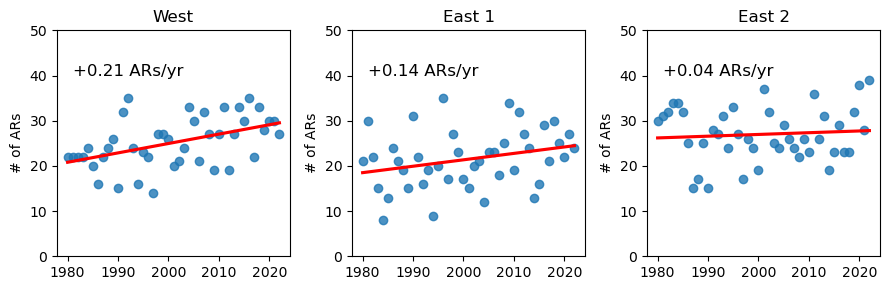

In [152]:
year_df = landfalling_catalog.groupby(['landfalling_year', 'coarser_region'], as_index=False).size()
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(9,3))
coord = 0
for label in region_masks_coarser.keys():
    cur_ax =axs[coord%3]

    year_region_df = year_df[year_df.coarser_region == label]
    sns.regplot(data=year_region_df, x='landfalling_year', y='size', ci=None, line_kws={"color": "red"}, ax=cur_ax)
    ar_rate = round(stats.linregress(year_region_df.landfalling_year, year_region_df['size'])[0], 2)
    text = f'+{ar_rate} ARs/yr'
    cur_ax.set_title(label)
    cur_ax.set_ylim([0, 50])
    cur_ax.text(1981, 40, s=text, fontsize=12)
    cur_ax.set_xlabel('')
    cur_ax.set_ylabel('# of ARs')

    coord += 1

fig.tight_layout()

fig.savefig(str(home_dir) + '/plots/paper_plots/regional_count_trends.png', dpi=100)

In [154]:
year_df.groupby('coarser_region')['size'].describe()

,count,mean,std,min,25%,50%,75%,max
coarser_region,,,,,,,,
East 1,43.0,21.488372,6.397068,8.0,17.0,21.0,25.0,35.0
East 2,43.0,27.000000,5.984106,15.0,23.5,26.0,31.5,39.0
West,43.0,25.162791,5.554622,14.0,22.0,24.0,30.0,35.0


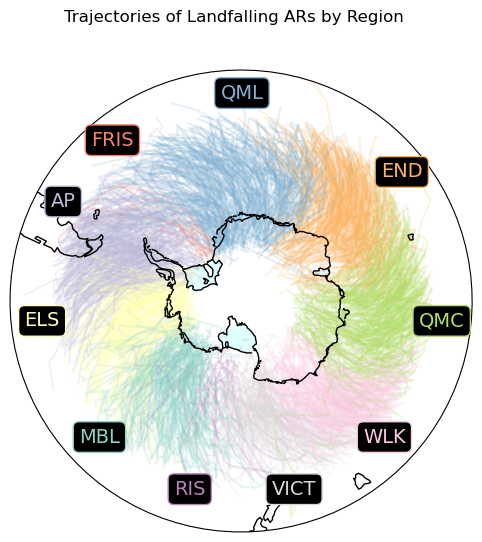

In [29]:
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory
    ax.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color=color_mapping[row.region], alpha=0.2)

for label in region_defs.keys():
    if label == 'East 2':
        ax.text((region_defs[label][0] + region_defs[label][1])/2 + 180, -45, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping[label], zorder=40)
    else:
        ax.text((region_defs[label][0] + region_defs[label][1])/2, -45, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping[label], zorder=40)



ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
#ax.gridlines(alpha=0.5, zorder=33)
fig.suptitle('Trajectories of Landfalling ARs by Region')
fig.savefig(str(home_dir) + '/plots/paper_plots/regional_trajectory_map.png', dpi=100)

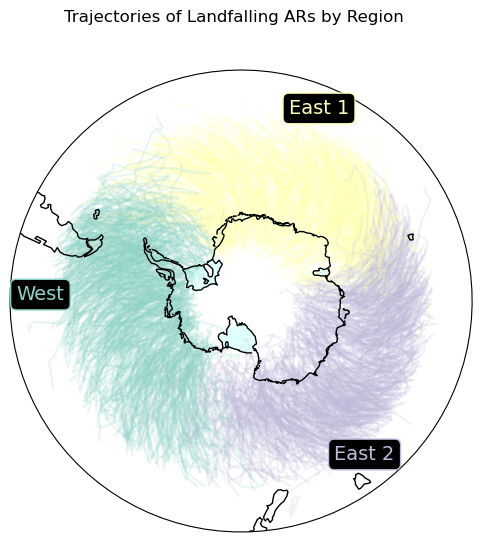

In [30]:
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory
    ax.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color=color_mapping_coarser[row.coarser_region], alpha=0.2)

for label in region_defs_coarser.keys():
    if label == 'East 2':
        ax.text((region_defs_coarser[label][0] + region_defs_coarser[label][1])/2 + 180, -45, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping_coarser[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping_coarser[label], zorder=40)
    else:
        ax.text((region_defs_coarser[label][0] + region_defs_coarser[label][1])/2, -45, label, fontsize=14, horizontalalignment='center', bbox=dict(facecolor='black', edgecolor=color_mapping_coarser[label], boxstyle='round'), transform=ccrs.PlateCarree(), color=color_mapping_coarser[label], zorder=40)



ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
#ax.gridlines(alpha=0.5, zorder=33)
fig.suptitle('Trajectories of Landfalling ARs by Region')
fig.savefig(str(home_dir) + '/plots/paper_plots/regional_trajectory_map.png', dpi=100)

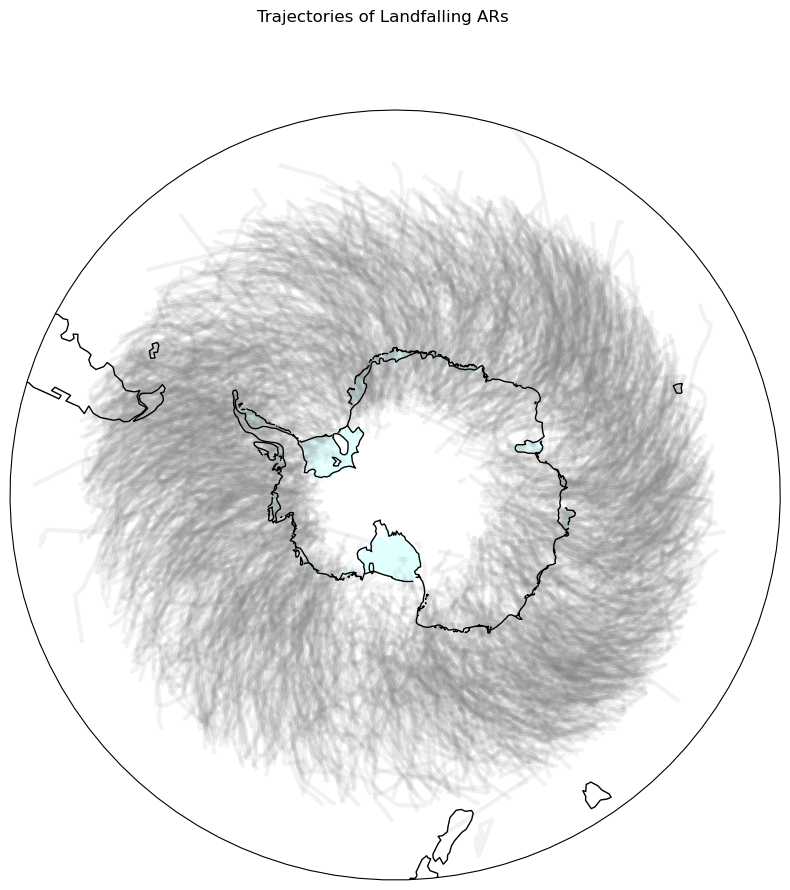

In [31]:
fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))
for index, row in landfalling_catalog.iterrows():
    trajectory = row.trajectory
    ax.plot(trajectory.avg_lon, trajectory.avg_lat, transform=ccrs.Geodetic(), color='gray', alpha=0.1, linewidth=3)


ax.set_extent([-180,180,-90,-39], ccrs.PlateCarree())
ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
ax.add_feature(ice_shelf_poly,linewidth=3)
ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
ax.add_feature(ice_shelf_line,linewidth=1,zorder=13)
ax.coastlines(resolution='110m',linewidth=1,zorder=32)

    
# Map extent 
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
#ax.gridlines(alpha=0.5, zorder=33)

fig.suptitle('Trajectories of Landfalling ARs')
fig.savefig(str(home_dir) + '/plots/paper_plots/trajectory_map.png', dpi=100)

Plots of landfalling quantities by region

In [32]:
landfalling_catalog['cumulative_snowfall_ais'] = landfalling_catalog['cumulative_snowfall_ais']/10**13
landfalling_catalog['cumulative_rainfall_ais'] = landfalling_catalog['cumulative_rainfall_ais']/10**13
landfalling_catalog = landfalling_catalog[landfalling_catalog.max_ocean_SLP_gradient >= 0]


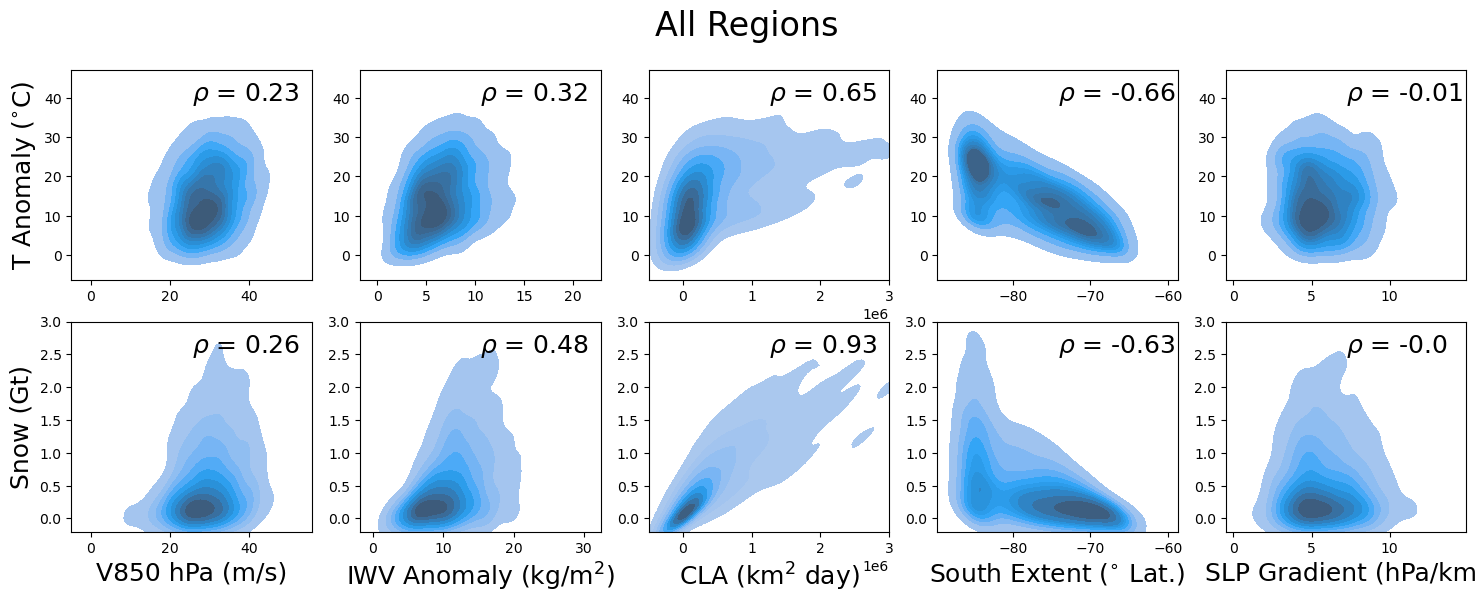

In [33]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('All Regions', fontsize=24)

catalog = landfalling_catalog

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_anomaly_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_anomaly_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV Anomaly (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

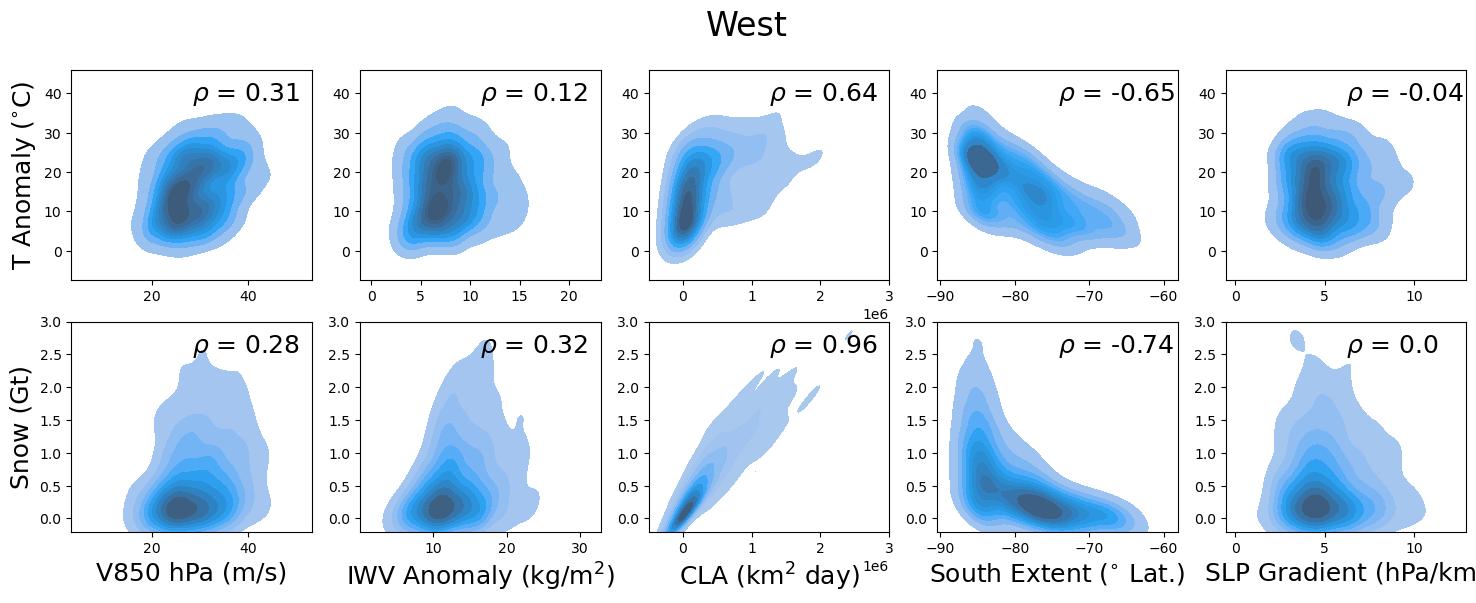

In [32]:
from scipy.stats import pearsonr
from scipy.stats import spearmanr

fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('West', fontsize=24)

catalog = landfalling_catalog[landfalling_catalog.coarser_region == 'West']

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_anomaly_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_anomaly_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV Anomaly (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

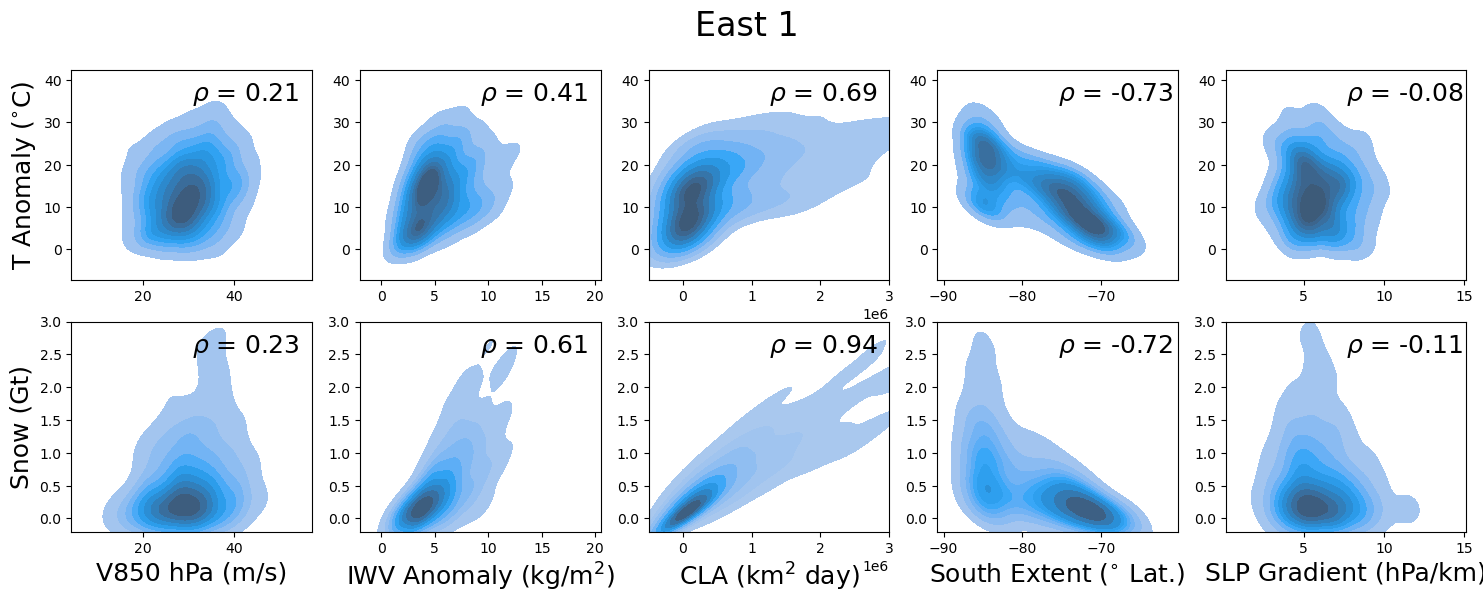

In [123]:
fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('East 1', fontsize=24)

catalog = landfalling_catalog[landfalling_catalog.coarser_region == 'East 1']

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_anomaly_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_anomaly_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_anomaly_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV Anomaly (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

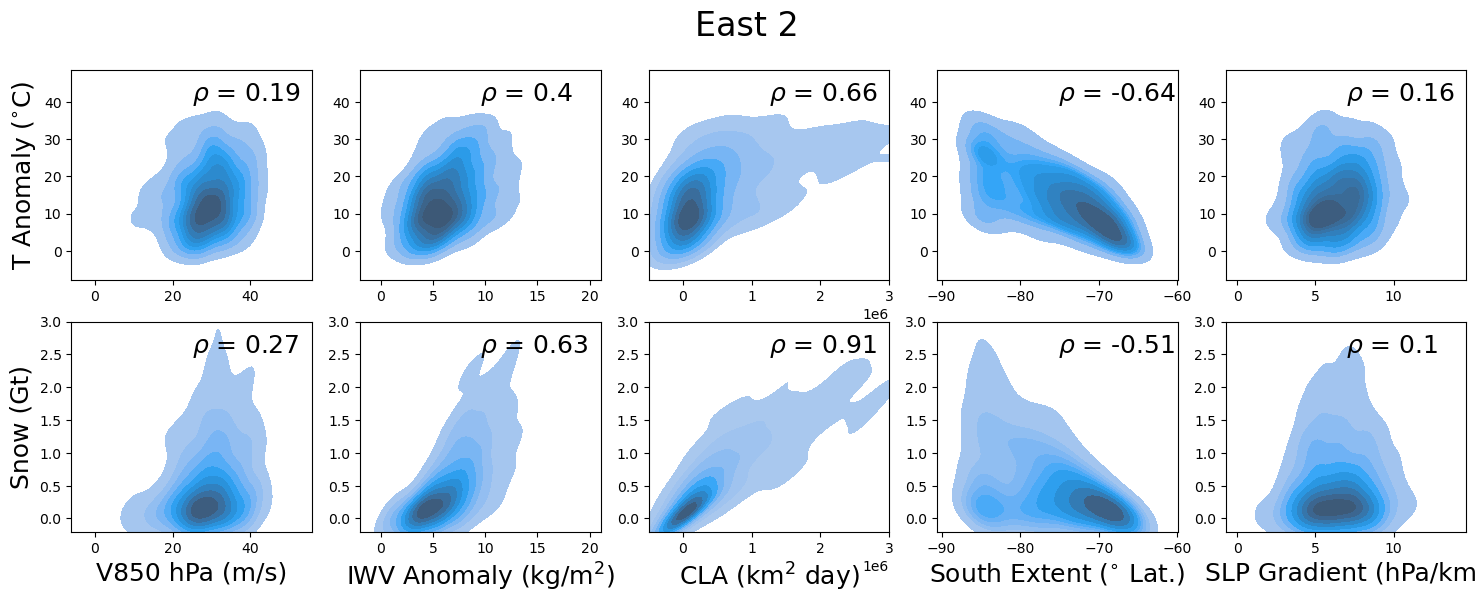

In [124]:
fig, axs = plt.subplots(nrows=2, ncols=5)
fig.set_size_inches(18, 6)
fig.suptitle('East 2', fontsize=24)

catalog = landfalling_catalog[landfalling_catalog.coarser_region == 'East 2']

impact1 = "max_T2M_anomaly_ais"
impact2 = "cumulative_snowfall_ais"

#fig.suptitle('Pairwise Relationships between Impacts and Covariates', fontsize=22)

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact1, fill=True, ax=axs[0,0])
axs[0,0].set_xlabel('')
axs[0,0].set_ylabel('T Anomaly ($^{\\circ}$C)', fontsize=18)
axs[0,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_anomaly_ais, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_anomaly_ais", y=impact1, fill=True, ax=axs[0,1])
axs[0,1].set_xlabel('')
axs[0,1].set_ylabel('')
axs[0,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact1, fill=True, ax=axs[0,2])
axs[0,2].set_xlabel('')
axs[0,2].set_ylabel('')
axs[0,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[0,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact1, fill=True, ax=axs[0,3])
axs[0,3].set_xlabel('')
axs[0,3].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact1]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact1, fill=True, ax=axs[0,4])
axs[0,4].set_xlabel('')
axs[0,4].set_ylabel('')
#axs[3].set_xlim(, 4*(10**6))
axs[0,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_landfalling_v850hPa, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_landfalling_v850hPa", y=impact2, fill=True, ax=axs[1,0])
axs[1,0].set_xlabel('V850 hPa (m/s)', fontsize=18)
axs[1,0].set_ylabel('Snow (Gt)', fontsize=18)
axs[1,0].set_ylim(-0.2, 3)
axs[1,0].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_IWV_ais, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_IWV_anomaly_ais", y=impact2, fill=True, ax=axs[1,1])
axs[1,1].set_xlabel('IWV Anomaly (kg/m$^{2}$)', fontsize=18)
axs[1,1].set_ylabel('')
axs[1,1].set_ylim(-0.2, 3)
axs[1,1].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.cumulative_landfalling_area, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="cumulative_landfalling_area", y=impact2, fill=True, ax=axs[1,2])
axs[1,2].set_xlabel('CLA (km$^{2} $ day)', fontsize=18)
axs[1,2].set_xlim(-0.5*(10**6), 3*(10**6))
axs[1,2].set_ylabel('')
axs[1,2].set_ylim(-0.2, 3)
axs[1,2].annotate(text='$\\rho$ = '+ str(corr), xy=(0.50, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_south_extent, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_south_extent", y=impact2, fill=True, ax=axs[1,3])
axs[1,3].set_xlabel('South Extent ($^{\\circ}$ Lat.)', fontsize=18)
axs[1,3].set_ylabel('')
axs[1,3].set_ylim(-0.2, 3)
axs[1,3].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);

corr = round(spearmanr(catalog.max_ocean_SLP_gradient, catalog[impact2]).statistic, 2)
sns.kdeplot(data=catalog, x="max_ocean_SLP_gradient", y=impact2, fill=True, ax=axs[1,4])
axs[1,4].set_xlabel('SLP Gradient (hPa/km)', fontsize=18)
axs[1,4].set_ylabel('')
axs[1,4].set_ylim(-0.2, 3)
axs[1,4].annotate(text='$\\rho$ = '+ str(corr), xy=(0.5, 0.85), xycoords='axes fraction', fontsize=18);